<a href="https://colab.research.google.com/github/vinol3/WB2_lab1/blob/main/tutorial_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import time
import random
import numpy as np
from tqdm import tqdm
from copy import deepcopy
from sklearn.model_selection import train_test_split

import torch
import torch.nn.functional as F

import torchvision
from torchvision import transforms as T

import matplotlib.pyplot as plt

In [2]:
SEED = 42

def seed_everything(seed: int=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)

In [3]:
# define the transform to apply to the data - resize to 224x224 and convert to tensor.
transform = T.Compose([T.Resize((224, 224)), T.ToTensor()])

# Load the datasets
path_where_data_is_stored = '../data' # change this to the path where you want to store the data

### START CODE HERE ### (≈ 2 lines) you need to load train and test `GTSRB` dataset from PyTorch official page.
full_dataset = torchvision.datasets.GTSRB(root=path_where_data_is_stored, split="train", download=True, transform=transform)
dataset_test = torchvision.datasets.GTSRB(root=path_where_data_is_stored, split="test", download=True, transform=transform)
### END CODE HERE ###

# Lets now split the dataset into a SSL dataset and a classification dataset
SSL_SIZE = 0.6 # percentage of the dataset to use for training
targets = np.array([y for _, y in full_dataset])
SSL_indices, classification_indices = train_test_split(
    np.arange(len(targets)),
    test_size=1-SSL_SIZE,
    random_state=SEED,
    stratify=targets
)
SSL_dataset = torch.utils.data.Subset(full_dataset, SSL_indices)
classification_dataset = torch.utils.data.Subset(full_dataset, classification_indices)

print(f"Train full dataset size: {len(full_dataset)}")
print(f"Train SSL dataset size: {len(SSL_dataset)}")
print(f"Train classification dataset size: {len(classification_dataset)}")
print(f"Test dataset size: {len(dataset_test)}")

100%|██████████| 187M/187M [00:15<00:00, 12.4MB/s]
100%|██████████| 89.0M/89.0M [00:09<00:00, 9.36MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 209kB/s]


Train full dataset size: 26640
Train SSL dataset size: 15984
Train classification dataset size: 10656
Test dataset size: 12630


In [4]:
map_idx_to_class = [
    "Speed limit (20km/h)",
    "Speed limit (30km/h)",
    "Speed limit (50km/h)",
    "Speed limit (60km/h)",
    "Speed limit (70km/h)",
    "Speed limit (80km/h)",
    "End of speed limit (80km/h)",
    "Speed limit (100km/h)",
    "Speed limit (120km/h)",
    "No passing",
    "No passing for vehicles over 3.5 metric tons",
    "Right-of-way at the next intersection",
    "Priority road",
    "Yield",
    "Stop",
    "No vehicles",
    "Vehicles over 3.5 metric tons prohibited",
    "No entry",
    "General caution",
    "Dangerous curve to the left",
    "Dangerous curve to the right",
    "Double curve",
    "Bumpy road",
    "Slippery road",
    "Road narrows on the right",
    "Road work",
    "Traffic signals",
    "Pedestrians",
    "Children crossing",
    "Bicycles crossing",
    "Beware of ice/snow",
    "Wild animals crossing",
    "End of all speed and passing limits",
    "Turn right ahead",
    "Turn left ahead",
    "Ahead only",
    "Go straight or right",
    "Go straight or left",
    "Keep right",
    "Keep left",
    "Roundabout mandatory",
    "End of no passing",
    "End of no passing by vehicles over 3.5 metric tons"
]
angles = [0, 90, 180, 270]

In [5]:
image, target = next(iter(SSL_dataset))
image.shape, target, len(map_idx_to_class), len(angles)


(torch.Size([3, 224, 224]), 8, 43, 4)

In [6]:
# Rotation Dataset
class SSLRot(torch.utils.data.Dataset):
    def __init__(self, dataset: torch.utils.data.Dataset, angles: list[int]):
        super(SSLRot, self).__init__()
        self.original_dataset = dataset
        self.angles = angles

    def __len__(self):
        return len(self.original_dataset)

    def rand_rotate(self, img: torch.Tensor) -> tuple[torch.Tensor, int]:
        """
        Randomly rotates the image by 0, 90, 180, or 270 degrees.
        """
        ### START CODE HERE ###
        rot_label = torch.randint(0, len(self.angles), (1,)).item()
        angle = self.angles[rot_label]
        rotated_img = T.functional.rotate(img, angle)
        ### END CODE HERE ###
        return rotated_img, rot_label

    def __getitem__(self, idx):
        ### START CODE HERE ###
        img, _ = self.original_dataset[idx]
        rotated_img, rot_label = self.rand_rotate(img)
        ### END CODE HERE ###
        return rotated_img, torch.tensor(rot_label, dtype=torch.long)

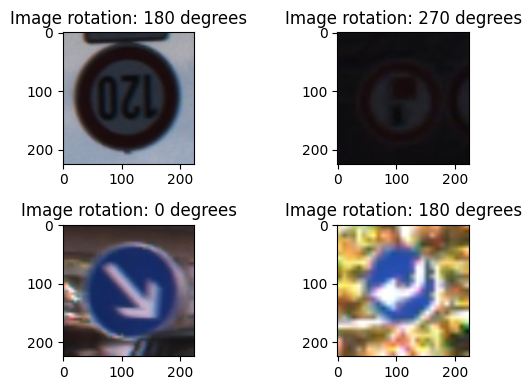

In [7]:
rotation_dataset_train = SSLRot(SSL_dataset, angles)
rotation_dataset_test = SSLRot(dataset_test, angles)

fig, ax = plt.subplots(2, 2, figsize=(6, 4))
img, rot = rotation_dataset_train[0]
ax[0, 0].imshow(img.permute(1, 2, 0))
ax[0, 0].set_title(f"Image rotation: {angles[rot]} degrees")

img, rot = rotation_dataset_train[1]
ax[0, 1].imshow(img.permute(1, 2, 0))
ax[0, 1].set_title(f"Image rotation: {angles[rot]} degrees")

img, rot = rotation_dataset_test[2]
ax[1, 0].imshow(img.permute(1, 2, 0))
ax[1, 0].set_title(f"Image rotation: {angles[rot]} degrees")

img, rot = rotation_dataset_test[3]
ax[1, 1].imshow(img.permute(1, 2, 0))
ax[1, 1].set_title(f"Image rotation: {angles[rot]} degrees")
plt.tight_layout()
plt.show()

In [8]:
def load_resnet_rotation(number_of_classes=4):
    ### START CODE HERE ### (≈ 2 lines)
    model = torchvision.models.resnet18(weights=None)
    model.fc = torch.nn.Linear(model.fc.in_features, number_of_classes)
    ### END CODE HERE ###
    return model

def test_load_resnet_rotation():
    model = load_resnet_rotation()
    x, y = rotation_dataset_train[0]
    x = x.unsqueeze(0)  # Add a batch dimension
    y = y.unsqueeze(0)  # Add a batch dimension

    with torch.no_grad():
        pred_y = model(x)

    loss = F.cross_entropy(pred_y, y)
    pred_y_class = torch.argmax(pred_y, dim=1)
    print(f"Input shape: {x.shape}, Model output: {pred_y.shape}, Model predicted {pred_y_class}, Ground truth: {y}, Loss: {loss.item()}")

test_load_resnet_rotation()

Input shape: torch.Size([1, 3, 224, 224]), Model output: torch.Size([1, 4]), Model predicted tensor([3]), Ground truth: tensor([0]), Loss: 1.637805700302124


In [9]:
def train_one_epoch(model: torch.nn.Module, optimizer: torch.optim.Optimizer, train_loader: torch.utils.data.DataLoader, criterion: torch.nn.Module, device=torch.device):
    """Train the model for one epoch.
    Args:
        model (torch.nn.Module): The model to train.
        optimizer (torch.optim.Optimizer): The optimizer to use.
        train_loader (torch.utils.data.DataLoader): The training data loader.
        criterion (torch.nn.Module): The loss function.
        device (torch.device): The device to use for training (CPU or GPU).
    Returns:
        tuple: The average loss and accuracy for the epoch.
    """
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in tqdm(train_loader, desc="Training"):
        inputs, targets = inputs.to(device), targets.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        # Statistics
        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    train_loss = total_loss / total
    train_acc = 100.0 * correct / total

    return train_loss, train_acc

def validate(model: torch.nn.Module, val_loader: torch.utils.data.DataLoader, device=torch.device) -> float:
    """Validate the model.
    Args:
        model (nn.Module): The model to validate.
        val_loader (torch.utils.data.DataLoader): The validation data loader.
        device (torch.device): The device to use for validation (CPU or GPU).

    Returns:
        float: The average accuracy for the validation set.
    """
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in tqdm(val_loader, desc="Validating"):
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward
            outputs = model(inputs)

            # Statistics
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    val_acc = 100.0 * correct / total

    return val_acc

def visualize_predictions(model: torch.nn.Module, dataset: torch.utils.data.Dataset, device: torch.device, class_names: list[str], num_images: int=5):
    """Visualize predictions of the model on a subset of the dataset.
    Args:
        model (torch.nn.Module): The model to use for predictions.
        dataset (torch.utils.data.Dataset): The dataset to visualize.
        device (torch.device): The device to use for predictions (CPU or GPU).
        class_names (list[str]): The list of class names.
        num_images (int): The number of images to visualize.

    """
    model.eval()
    indices = random.sample(range(len(dataset)), num_images)

    _, axes = plt.subplots(1, num_images, figsize=(15, 5))

    with torch.no_grad():
        for i, idx in enumerate(indices):
            img, label = dataset[idx]
            img = img.unsqueeze(0).to(device)
            output = model(img)
            pred_label = output.argmax(dim=1).item()

            axes[i].imshow(img.squeeze(0).permute(1, 2, 0).cpu())
            axes[i].set_title(f"Pred: {class_names[pred_label]}\nTrue: {class_names[label]}")
            axes[i].axis('off')

    plt.show()

In [11]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

print(f"You are currently using a: {device.upper()}")

You are currently using a: CUDA


In [12]:
def train(model: torch.nn.Module, train_loader: torch.utils.data.DataLoader, val_loader: torch.utils.data.DataLoader, optimizer: torch.optim.Optimizer, criterion: torch.nn.Module, num_epochs: int=10, device=torch.device) -> tuple[list[float], list[float]]:
    train_accs = []
    val_accs = []

    ### START CODE HERE ###
    model.to(device)

    for epoch in range(num_epochs):

        model.train()
        correct, total = 0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            preds = model(x)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()

            predicted = torch.argmax(preds, dim=1)
            correct += (predicted == y).sum().item()
            total += y.size(0)

        train_acc = correct / total
        train_accs.append(train_acc)

        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)

                preds = model(x)
                predicted = torch.argmax(preds, dim=1)

                correct += (predicted == y).sum().item()
                total += y.size(0)

        val_acc = correct / total
        val_accs.append(val_acc)
    ### END CODE HERE ###

    return train_accs, val_accs

In [13]:
### PARAMETERS ###
BATCH_SIZE = 64
NUM_EPOCHS = 4
LEARNING_RATE = 0.001
NUM_WORKERS = 0
NUMBER_OF_CLASSES = 4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [14]:
# Get the data loaders
train_dl = torch.utils.data.DataLoader(rotation_dataset_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_dl = torch.utils.data.DataLoader(rotation_dataset_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Load the model
ssl_model = load_resnet_rotation(NUMBER_OF_CLASSES)
ssl_model = ssl_model.to(device)

# Define the optimizer
optimizer = torch.optim.AdamW(ssl_model.parameters(), lr=LEARNING_RATE)

# Define the loss function
criterion = torch.nn.CrossEntropyLoss()

# Train the model
train_accs, val_accs = train(ssl_model, train_dl, val_dl, optimizer, criterion, num_epochs=NUM_EPOCHS, device=device)

### START CODE HERE ### (≈ 1 lines)
torch.save({"model_state_dict": ssl_model.state_dict(), "train_accs": train_accs, "val_accs": val_accs}, "ssl_rotation_model.pth")
### END CODE HERE ###

Epoch 1/4 | Train Acc: 0.3317 | Val Acc: 0.3346
Epoch 2/4 | Train Acc: 0.7242 | Val Acc: 0.7453
Epoch 3/4 | Train Acc: 0.8873 | Val Acc: 0.8926
Epoch 4/4 | Train Acc: 0.9354 | Val Acc: 0.9196


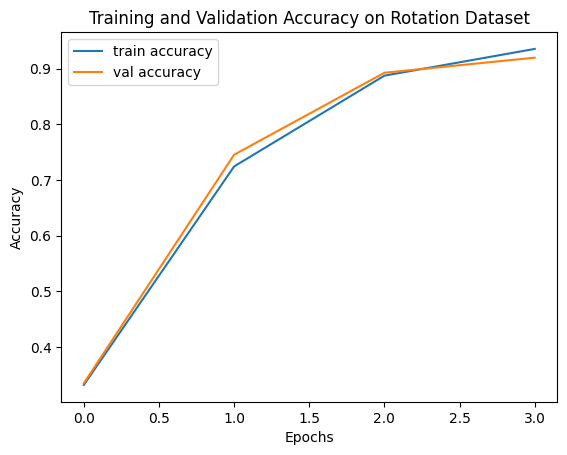

In [15]:
plt.plot(train_accs, label='train accuracy')
plt.plot(val_accs, label='val accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy on Rotation Dataset')
plt.legend()
plt.show()

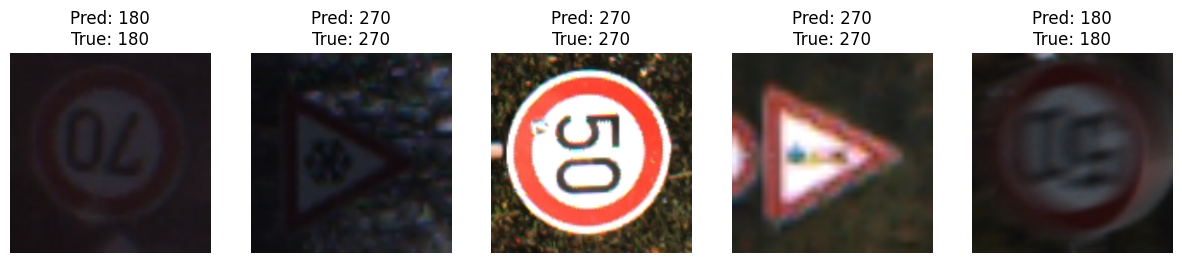

In [16]:
visualize_predictions(ssl_model, rotation_dataset_test, num_images=5, device=device, class_names=angles)

In [17]:
### PARAMETERS ###
BATCH_SIZE = 64
NUM_EPOCHS = 6
LEARNING_RATE = 0.001
NUM_WORKERS = 0
NUMBER_OF_CLASSES = 43
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [18]:
# Get the data loaders
train_dl = torch.utils.data.DataLoader(classification_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_dl = torch.utils.data.DataLoader(dataset_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Load the model
empty_model = load_resnet_rotation(NUMBER_OF_CLASSES)
empty_model = empty_model.to(device)

# Define the optimizer
optimizer = torch.optim.AdamW(empty_model.parameters(), lr=LEARNING_RATE)

# Define the loss function
criterion = torch.nn.CrossEntropyLoss()

# Train the model
train_accs, val_accs = train(empty_model, train_dl, val_dl, optimizer, criterion, num_epochs=NUM_EPOCHS, device=device)

Epoch 1/6 | Train Acc: 0.2266 | Val Acc: 0.3023
Epoch 2/6 | Train Acc: 0.4892 | Val Acc: 0.4983
Epoch 3/6 | Train Acc: 0.8255 | Val Acc: 0.7572
Epoch 4/6 | Train Acc: 0.9660 | Val Acc: 0.8381
Epoch 5/6 | Train Acc: 0.9905 | Val Acc: 0.9236
Epoch 6/6 | Train Acc: 0.9965 | Val Acc: 0.9413


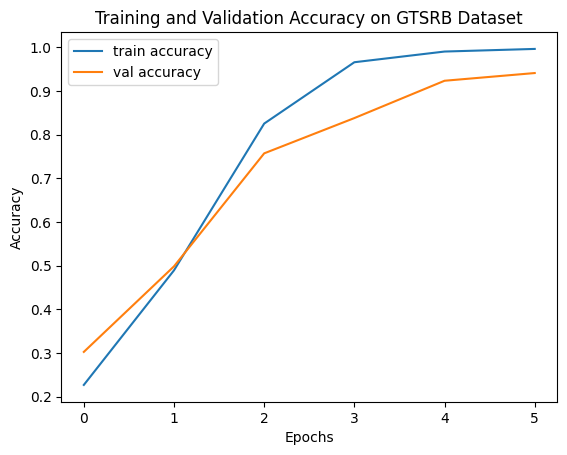

In [19]:
plt.plot(train_accs, label='train accuracy')
plt.plot(val_accs, label='val accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy on GTSRB Dataset')
plt.legend()
plt.show()

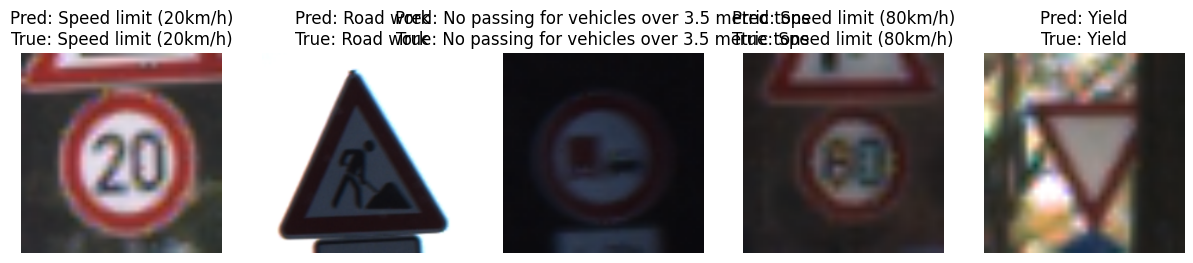

In [20]:
visualize_predictions(empty_model, dataset_test, num_images=5, device=device, class_names=map_idx_to_class)

In [21]:
### PARAMETERS ###
BATCH_SIZE = 64
NUM_EPOCHS = 20
LEARNING_RATE = 0.001
NUM_WORKERS = 0
NUMBER_OF_CLASSES = 43
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [22]:
# Get the data loaders
train_dl = torch.utils.data.DataLoader(classification_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_dl = torch.utils.data.DataLoader(dataset_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Freeze the model
model = deepcopy(ssl_model)

### CODE HERE ### (≈ 3 lines)
for param in model.parameters():
    param.requires_grad = False
model.fc = torch.nn.Linear(model.fc.in_features, NUMBER_OF_CLASSES)
### END CODE HERE ###
model = model.to(device)

# Define the optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

# Define the loss function
criterion = torch.nn.CrossEntropyLoss()

# Train the model
train_accs, val_accs = train(model, train_dl, val_dl, optimizer, criterion, num_epochs=NUM_EPOCHS, device=device)

Epoch 1/20 | Train Acc: 0.1772 | Val Acc: 0.2337
Epoch 2/20 | Train Acc: 0.2648 | Val Acc: 0.2553
Epoch 3/20 | Train Acc: 0.3162 | Val Acc: 0.3047
Epoch 4/20 | Train Acc: 0.3459 | Val Acc: 0.2959
Epoch 5/20 | Train Acc: 0.3695 | Val Acc: 0.3500
Epoch 6/20 | Train Acc: 0.3953 | Val Acc: 0.3551
Epoch 7/20 | Train Acc: 0.4143 | Val Acc: 0.3808
Epoch 8/20 | Train Acc: 0.4290 | Val Acc: 0.3719
Epoch 9/20 | Train Acc: 0.4459 | Val Acc: 0.3955
Epoch 10/20 | Train Acc: 0.4613 | Val Acc: 0.4216
Epoch 11/20 | Train Acc: 0.4732 | Val Acc: 0.4222
Epoch 12/20 | Train Acc: 0.4888 | Val Acc: 0.4195
Epoch 13/20 | Train Acc: 0.4992 | Val Acc: 0.4386
Epoch 14/20 | Train Acc: 0.5055 | Val Acc: 0.4545
Epoch 15/20 | Train Acc: 0.5126 | Val Acc: 0.4641
Epoch 16/20 | Train Acc: 0.5277 | Val Acc: 0.4583
Epoch 17/20 | Train Acc: 0.5369 | Val Acc: 0.4667
Epoch 18/20 | Train Acc: 0.5439 | Val Acc: 0.4923
Epoch 19/20 | Train Acc: 0.5525 | Val Acc: 0.4622
Epoch 20/20 | Train Acc: 0.5485 | Val Acc: 0.4874


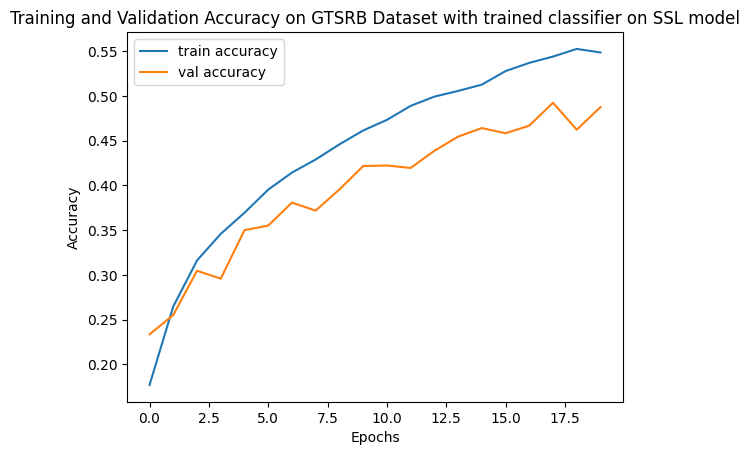

In [23]:
plt.plot(train_accs, label='train accuracy')
plt.plot(val_accs, label='val accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy on GTSRB Dataset with trained classifier on SSL model')
plt.legend()
plt.show()

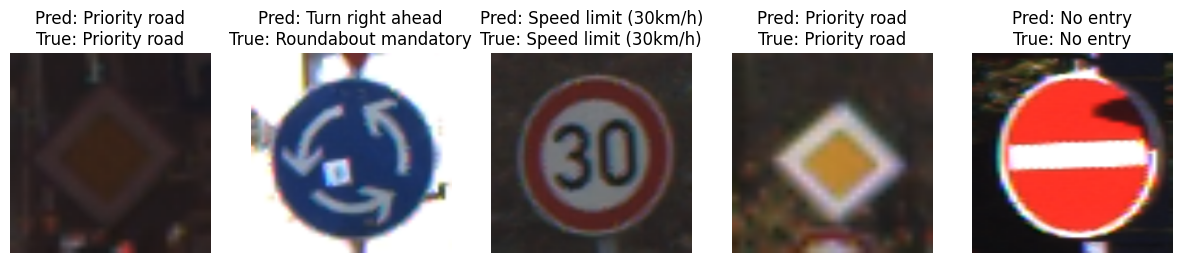

In [24]:
visualize_predictions(model, dataset_test, num_images=5, device=device, class_names=map_idx_to_class)

In [25]:
### PARAMETERS ###
BATCH_SIZE = 64
NUM_EPOCHS = 4
LEARNING_RATE = 0.0001
NUM_WORKERS = 0
NUMBER_OF_CLASSES = 43
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [26]:
# Get the data loaders
train_dl = torch.utils.data.DataLoader(classification_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_dl = torch.utils.data.DataLoader(dataset_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Freeze the model
model_finetune = deepcopy(ssl_model)

### CODE HERE ### (≈ 1 line) substitute the last layer with a new one that has the number of classes equal to `NUMBER_OF_CLASSES`.
model_finetune.fc = torch.nn.Linear(model_finetune.fc.in_features, NUMBER_OF_CLASSES)
### END CODE HERE ###
model_finetune = model_finetune.to(device)

# Define the optimizer
optimizer = torch.optim.AdamW(model_finetune.parameters(), lr=LEARNING_RATE)

# Define the loss function
criterion = torch.nn.CrossEntropyLoss()

# Train the model
train_accs, val_accs = train(model_finetune, train_dl, val_dl, optimizer, criterion, num_epochs=NUM_EPOCHS, device=device)

Epoch 1/4 | Train Acc: 0.3589 | Val Acc: 0.5637
Epoch 2/4 | Train Acc: 0.7355 | Val Acc: 0.8080
Epoch 3/4 | Train Acc: 0.9159 | Val Acc: 0.8927
Epoch 4/4 | Train Acc: 0.9786 | Val Acc: 0.9279


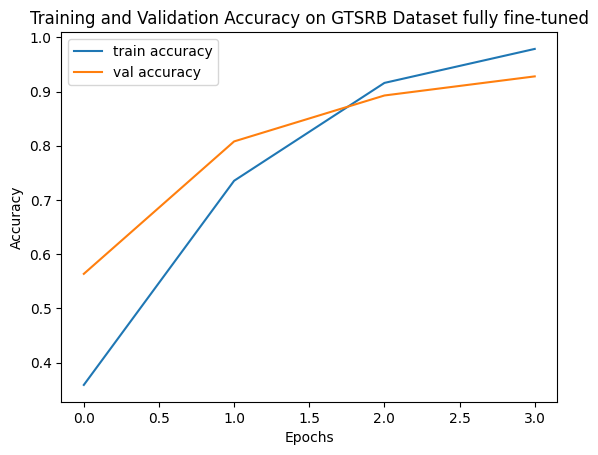

In [27]:
plt.plot(train_accs, label='train accuracy')
plt.plot(val_accs, label='val accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy on GTSRB Dataset fully fine-tuned')
plt.legend()
plt.show()

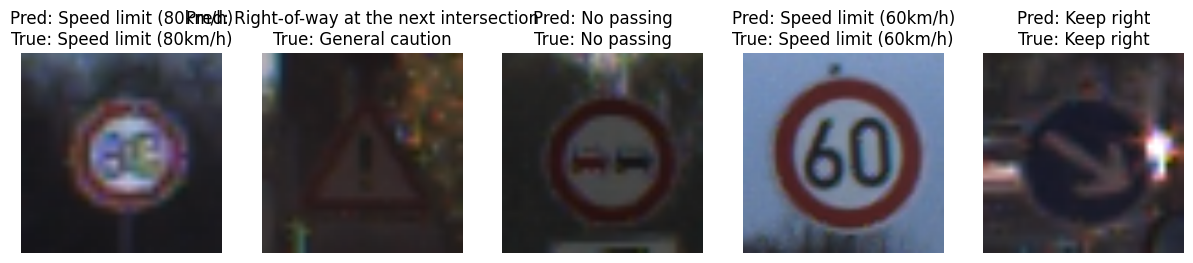

In [28]:
visualize_predictions(model_finetune, dataset_test, num_images=5, device=device, class_names=map_idx_to_class)

In [31]:
"""
1) Did the model trained on the SSL dataset perform better than the one trained only on the classification dataset?
Model trained only on the classification dataset did way better

2) Which training strategy performed better? The one where you trained the classifier head on top of the SSL model or the one where you finetuned the SSL model?
Finetuning the SSL model yielded better result

3) Besides the accuracy metric, what other benefits did you get from using the SSL model?
There was no accuracy benefit

4) What are your conclusions? Did you expect this? If not, why?
Did not expect the SSL based model to do so poorly

5) Was SSL useful in this case?
SSL was't useful
"""

'\nDid the model trained on the SSL dataset perform better than the one trained only on the classification dataset?\n\n\nWhich training strategy performed better? The one where you trained the classifier head on top of the SSL model or the one where you finetuned the SSL model?\nBesides the accuracy metric, what other benefits did you get from using the SSL model?\nWhat are your conclusions? Did you expect this? If not, why?\nWas SSL useful in this case?\n'